# Logistic Regression — From Scratch (NumPy only)

**Read `README.md` first.** Every block cites the section (§) it implements.

Compared to lesson 01, exactly **three lines change**: the prediction gains a sigmoid, the loss becomes cross-entropy, and… that's it — the gradients and training loop come out identical (README §3.4, the small miracle).

In [1]:
# Block 1 — Imports. Still NumPy only.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)

## Block 2 — Look at the data BEFORE modeling *(README §1)*

Logistic regression believes a **straight fence** can roughly split the classes. Eyeball check: if pass/fail were tangled together in patches, we'd stop here.

   hours_studied  prev_score  passed
0            6.3        31.0       0
1            9.0        74.0       1
2            7.8        86.0       1
3            2.3        66.0       0
4            3.0        81.0       1 

120 students, pass rate = 55%


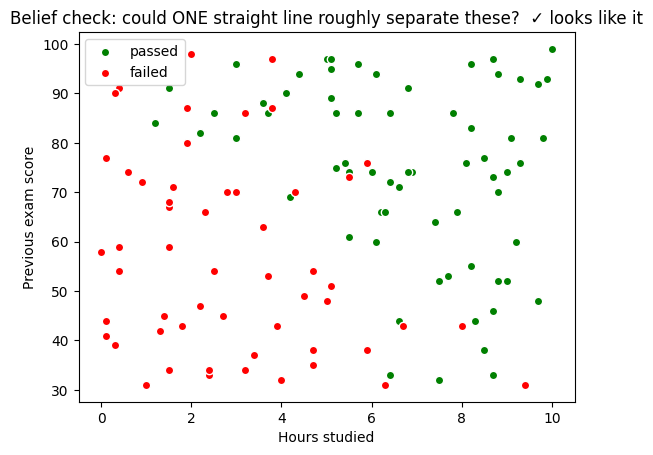

In [2]:
df = pd.read_csv("data/exam_data.csv")
print(df.head(), f"\n\n{len(df)} students, pass rate = {df.passed.mean():.0%}")

X = df[["hours_studied", "prev_score"]].values.astype(float)   # features — README §0 (lesson 01)
y = df["passed"].values                                        # labels: 1 = passed — README §0

plt.scatter(X[y==1,0], X[y==1,1], color="green", label="passed", edgecolor="white")
plt.scatter(X[y==0,0], X[y==0,1], color="red", label="failed", edgecolor="white")
plt.xlabel("Hours studied"); plt.ylabel("Previous exam score"); plt.legend()
plt.title("Belief check: could ONE straight line roughly separate these?  ✓ looks like it")
plt.show()

## Block 3 — Feature scaling *(README §4 — inherited from lesson 01)*

Hours run 0–10, previous scores 30–100. Same canyon problem, same fix.

In [3]:
mu, sd = X.mean(axis=0), X.std(axis=0)
Xs = (X - mu) / sd
print("means ≈", Xs.mean(axis=0).round(3), "  stds ≈", Xs.std(axis=0).round(3))

means ≈ [0. 0.]   stds ≈ [1. 1.]


## Block 4 — Predict: lesson 01's line + ONE new line of code *(README §3.1–3.2)*

The score `z = w·x + b` is unchanged. The sigmoid squashes it into a probability: huge z → ≈1, huge negative z → ≈0, zero → 0.5.

In [4]:
def sigmoid(z):
    """README §3.2 — any number in, probability out."""
    return 1 / (1 + np.exp(-z))

def predict_proba(Xs, w, b):
    """README §3.1 (the line) + §3.2 (the squash). This is a one-neuron neural network."""
    z = Xs @ w + b          # evidence score — lesson 01, verbatim
    return sigmoid(z)       # evidence → probability — the ONE new idea

## Block 5 — The loss: cross-entropy *(README §3.3)*

Charge −log(probability given to the truth): confident-and-right ≈ free, confident-and-wrong ≈ ruinous. (MSE would cap that punishment at 1 — see README fig 04.)

In [5]:
def cross_entropy(p, y_true):
    """README §3.3 — fear confident wrongness above all."""
    eps = 1e-12                       # keep log away from exactly 0 — a real-world guard rail
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

# Sanity check: a clueless model saying 0.5 for everyone should cost -log(0.5) ≈ 0.693
w0, b0 = np.zeros(2), 0.0
print("Loss before any learning:", cross_entropy(predict_proba(Xs, w0, b0), y).round(3))

Loss before any learning: 0.693


## Block 6 — The gradients: the small miracle *(README §3.4)*

Chain rule through sigmoid + cross-entropy collapses to **(guess − truth) × input** — the exact same form as lesson 01, Block 6. Compare them side by side; only the meaning of the guess changed (probability instead of number).

In [6]:
def gradients(Xs, y_true, w, b):
    """README §3.4 — identical form to lesson 01. The error at the output, flowing backward."""
    error = predict_proba(Xs, w, b) - y_true    # (guess − truth), per student
    dw = Xs.T @ error / len(y_true)             # mistakes with leverage → rotate the fence
    db = np.mean(error)                         # average mistake     → shift the fence
    return dw, db

## Block 7 — The training loop: unchanged since lesson 01 *(README §3.5)*

predict → error → gradient → nudge. Watch the loss fall and the fence rotate into place.

epoch   0 | loss 0.6480 | w=[0.099 0.064] b=0.015
epoch 100 | loss 0.2873 | w=[2.21  1.435] b=0.337
epoch 200 | loss 0.2781 | w=[2.623 1.731] b=0.383
epoch 300 | loss 0.2763 | w=[2.805 1.863] b=0.401
epoch 400 | loss 0.2758 | w=[2.897 1.93 ] b=0.409
epoch 499 | loss 0.2757 | w=[2.946 1.965] b=0.414


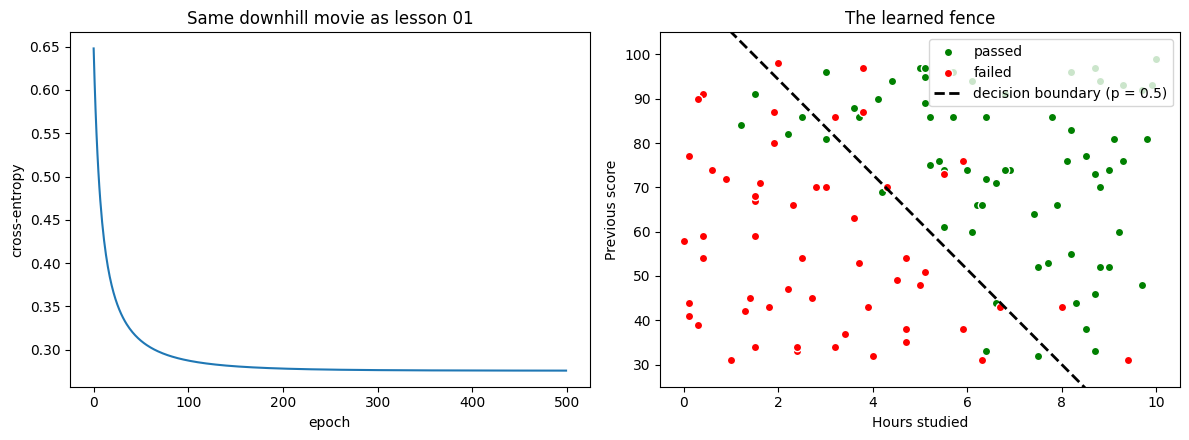

In [7]:
w, b = np.zeros(2), 0.0
lr, epochs = 0.3, 500
history = []
for epoch in range(epochs):
    dw, db = gradients(Xs, y, w, b)
    w -= lr * dw
    b -= lr * db
    history.append(cross_entropy(predict_proba(Xs, w, b), y))
    if epoch % 100 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:3d} | loss {history[-1]:.4f} | w={w.round(3)} b={b:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy")
axes[0].set_title("Same downhill movie as lesson 01")

# the learned fence, drawn in real units
ax = axes[1]
ax.scatter(X[y==1,0], X[y==1,1], color="green", label="passed", edgecolor="white")
ax.scatter(X[y==0,0], X[y==0,1], color="red", label="failed", edgecolor="white")
x0 = np.linspace(0, 10, 50)
x0s = (x0 - mu[0]) / sd[0]
x1 = (-(w[0] * x0s + b) / w[1]) * sd[1] + mu[1]     # where z = 0 → p = 0.5 (README §2.3)
ax.plot(x0, x1, "k--", lw=2, label="decision boundary (p = 0.5)")
ax.set_xlabel("Hours studied"); ax.set_ylabel("Previous score")
ax.set_ylim(25, 105); ax.legend(); ax.set_title("The learned fence")
plt.tight_layout(); plt.show()

## Block 8 — The new knob: sweep the threshold *(README §4, §5)*

The model outputs probabilities; WHERE we cut them into yes/no is our choice — and it trades precision against recall. Watch the trade happen live.

In [8]:
p = predict_proba(Xs, w, b)

print(" threshold | precision | recall | meaning")
print("-" * 62)
for t in [0.2, 0.5, 0.8]:
    yes = (p >= t).astype(int)
    TP = np.sum((yes == 1) & (y == 1)); FP = np.sum((yes == 1) & (y == 0))
    FN = np.sum((yes == 0) & (y == 1))
    prec = TP / (TP + FP) if TP + FP else float("nan")
    rec  = TP / (TP + FN)
    note = {0.2: "liberal: catches passers, cries wolf",
            0.5: "default: balanced",
            0.8: "strict: sure when it says pass, misses many"}[t]
    print(f"   {t:.1f}     |   {prec:.2f}    |  {rec:.2f}  | {note}")

# README §5: which row is 'best' depends on which mistake costs more. That's YOUR call, not the model's.

 threshold | precision | recall | meaning
--------------------------------------------------------------
   0.2     |   0.79    |  0.98  | liberal: catches passers, cries wolf
   0.5     |   0.86    |  0.86  | default: balanced
   0.8     |   0.93    |  0.76  | strict: sure when it says pass, misses many


## Block 9 — Reading the results: beyond accuracy *(README §5)*

Confusion matrix first, then the metrics. Accuracy last — and never alone.

In [9]:
yes = (p >= 0.5).astype(int)
TP = np.sum((yes==1)&(y==1)); FP = np.sum((yes==1)&(y==0))
TN = np.sum((yes==0)&(y==0)); FN = np.sum((yes==0)&(y==1))

print("Confusion matrix (threshold 0.5)")
print(f"                 predicted PASS   predicted FAIL")
print(f"actually PASS  |      {TP:3d} (TP)   |     {FN:3d} (FN)  ← missed passers")
print(f"actually FAIL  |      {FP:3d} (FP)   |     {TN:3d} (TN)")
print()
acc  = (TP + TN) / len(y)
prec = TP / (TP + FP)
rec  = TP / (TP + FN)
f1   = 2 * prec * rec / (prec + rec)
print(f"Accuracy  = {acc:.2f}   ← fraction correct (fine here: classes are ~balanced)")
print(f"Precision = {prec:.2f}   ← when it says PASS, it's right {prec:.0%} of the time")
print(f"Recall    = {rec:.2f}   ← it catches {rec:.0%} of the real passers")
print(f"F1        = {f1:.2f}   ← the balance of the two")

Confusion matrix (threshold 0.5)
                 predicted PASS   predicted FAIL
actually PASS  |       57 (TP)   |       9 (FN)  ← missed passers
actually FAIL  |        9 (FP)   |      45 (TN)

Accuracy  = 0.85   ← fraction correct (fine here: classes are ~balanced)
Precision = 0.86   ← when it says PASS, it's right 86% of the time
Recall    = 0.86   ← it catches 86% of the real passers
F1        = 0.86   ← the balance of the two


## Block 10 — Where does it fail? *(README §6)*

The final habit, classification edition: look at the *misclassified* points. If they scatter along the fence → the model is fine, the world is just noisy there. If they form a shape away from the fence → the straight-fence belief failed.

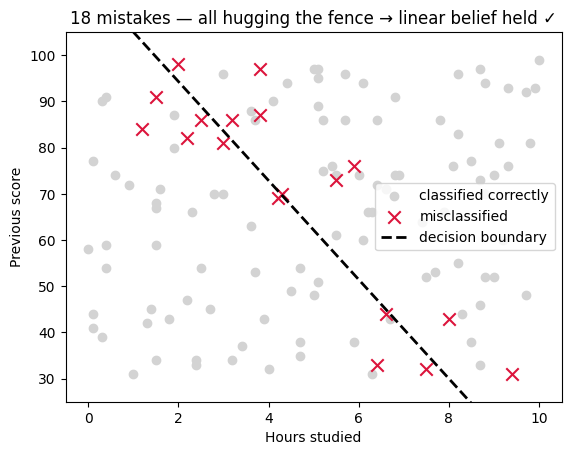

In [10]:
wrong = yes != y
plt.scatter(X[~wrong,0], X[~wrong,1], color="lightgray", label="classified correctly")
plt.scatter(X[wrong,0], X[wrong,1], color="crimson", marker="x", s=80, label="misclassified")
plt.plot(x0, x1, "k--", lw=2, label="decision boundary")
plt.xlabel("Hours studied"); plt.ylabel("Previous score"); plt.ylim(25, 105); plt.legend()
plt.title(f"{wrong.sum()} mistakes — all hugging the fence → linear belief held ✓")
plt.show()

---
## What you now own

- The sigmoid: how ONE function turns lesson 01's regression into classification
- Why cross-entropy replaces MSE for probabilities — and why the gradient still comes out as (guess − truth) × input
- The decision boundary as a learned fence, and the threshold as YOUR knob, not the model's
- Confusion matrix → precision → recall → the accuracy trap

**Next:** `logistic_regression_with_library.ipynb` to verify against sklearn — then folder `03`, where we throw away the entire gradient toolbox and classify by pure memory.